<img src="./figs/IOAI-Logo.png" alt="IOAI Logo" width="200" height="auto">

[IOAI 2025 (Beijing, China), Individual Contest](https://ioai-official.org/china-2025)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IOAI-official/IOAI-2025/blob/main/Individual-Contest/Radar/Radar.ipynb)

# Radar

## 1. Problem Description

Radar is a key technology in wireless communication, with widespread applications such as self-driving cars. It typically involves an antenna that transmits specific signals and receives their reflections from objects in the environment. By processing these signals, the system determines the angular direction, distance, and velocity of target objects.

In real-world applications, radar signal processing is challenging due to noise and reflections from non-target objects in the surroundings. For example, when attempting to detect pedestrians, the radar may also receive reflections from trees or other background objects, which can degrade accuracy. Your task is to use AI to analyze the signals received by the radar and identify the presence of a human at each position.

In this task, we provide an **indoor radar experiment dataset**, and your objective is to develop a model that performs **radar semantic segmentation**.


## 2. Dataset

To measure objects surrounding a radar, the following key parameters are used:

- **Range**: The straight-line distance between the radar and an object.
- **Azimuth**: The horizontal angle (left to right) between the radar and the object.
- **Elevation**: The vertical angle (up or down) of the object relative to the radar.
- **Velocity**: The speed at which the object is moving toward or away from the radar.

<img src="./figs/Radar Fig 1.png" width="300">


The radar data is processed into multiple **heatmaps**, each encoding the **received signal strength** at various positions and directions.

- **Static heatmaps** emphasize reflections from **stationary** objects.
- **Dynamic heatmaps** highlight changes caused by **moving** objects.

When no object is present at a specific location, the signal consists mostly of background noise and appears weak. In contrast, reflections from an object increase signal intensity, enabling detection of the object.

For example, the **static range-azimuth heatmap** represents signal strength across different distances (**range**) and horizontal angles (**azimuth**), mainly reflected by stationary objects.

Each sample in the dataset is stored in a `.mat.pt` file as a tensor of shape $7 \times 50 \times 181$, where:

- 7 is the number of maps (6 heatmaps + 1 semantic label map),
- 50 represents range bins (distance),
- 181 represents angular or velocity bins, covering angles from \-90° to \+90° in either the horizontal or vertical plane. You can assume that the velocity bins are also remapped from \-90° to \+90° for visualization consistency.
- each heatmap intensity value is normalized to [0, 1], representing received signal strength.

The 6 heatmaps are structured as follows:

- **Index 0**: Static range-azimuth heatmap
- **Index 1**: Dynamic range-azimuth heatmap
- **Index 2**: Static range-elevation heatmap
- **Index 3**: Dynamic range-elevation heatmap
- **Index 4**: Static range-velocity heatmap
- **Index 5**: Dynamic range-velocity heatmap

All values in heatmaps are **normalized**, so no unit conversion is required.

The **map at Index 6** is the semantic label map, stored in range-azimuth format.

- **-1**: Background (no target)
- **0**: Suitcase
- **1**: Chair
- **2**: Human
- **3**: Wall

This is the visualization of 1.mat.pt in training_set:

<img src="./figs/Radar Fig 2.png" width="675">

Here is part of a sample from the dataset:

<img src="./figs/Radar Fig 3.png" width="675">


Data scale: 1800 samples in the training set, 500 samples in the validation set, and 500 samples in the test set.

## 3\. Task

Your task is to develop a model that takes the **first six heatmaps** (indices 0 to 5) as input, and predicts the **semantic label map** (index 6) as the output. The goal is to accurately identify what the target is(-1 to 3) at each location in the radar’s field of view.

1. **Input**: A tensor of shape $6 \times 50 \times 181$, representing six radar heatmaps.
2. **Output**: A tensor of shape $50 \times 181$, representing the target semantic label map.


## 4\. Submission

Please submit a file named `submission.ipynb`. The output is a zip file named "submission.zip", which contains two tables `submission_val.csv` and `submission_test.csv` corresponding to the prediction results of the validation set and the test set respectively.

**Note:** The output table should have a header, the data in the table is not the actual solved data, it is only used as an example of the submission format.

| filename | pixel_0 | pixel_1 | ... | pixel_9049 |
| :------: | :-----: | ------- | --- | ---------- |
| 1.mat.pt |   -1    | -1      | ... | -1         |
|   ...    |   ...   | ...     | ... | ...        |

## 5\. Score

The score is based on the **accuracy of label recognition**. Correctly identifying target points is weighted more heavily than correctly identifying background points.

### Scoring Criteria:

* Each correctly identified **background pixel** earns **1 point**.

* Each correctly identified **non-background pixel** earns **50 points**.

* The final score is normalized to a **0-1 point** by comparing it to the maximum possible score.

### Formula：
$$
Score = \frac{|C_{0,correct}| \times 1 + |C_{1,correct}| \times bonus}{|C_0| \times 1 + |C_1| \times bonus}
$$
where:

$$
\begin{aligned}
I &= \{1, 2, \dots, 50\times 181\}\\
C_0 &= \{i \in I \mid y_i = -1\}\\
C_1 &= \{i \in I \mid y_i \neq -1\}\\
C_{0,correct} &= \{i \in C_0 \mid p_i = y_i\}\\
C_{1,correct} &= \{i \in C_1 \mid p_i = y_i\}\\
\end{aligned}
$$


### Example

For a $3\times3$ heatmap, assume the Ground Truth is:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
1 & 2 & 3 \\
-1 & -1 & -1
\end{bmatrix}
$$

The intenteded result is:

$$
\begin{bmatrix}
-1 & 1 & -1 \\
-1 & 2 & -1 \\
-1 & 3 & -1
\end{bmatrix}
$$

Then there are four correctly identified `-1` and one correctly identified `2`. Your score is 4 + 50 = 54 points. The maximum possible score is 6 + 50 * 3 = 156, that is, the score for six background pixels and three non-background pixels. Your normalized score is 54 / 156 = 0.346.

$$
Score = \frac{4 \times 1 + 1 \times 50}{6 \times 1 + 3 \times 50}=0.346
$$

## 6. Baseline and Training Set

- Below you can find the baseline solution.
- The dataset is in `training_set` folder.
- The highest score by the Scientific Committee for this task is 0.90 in Leaderboard B, this score is used for score unification.
- The baseline score by the Scientific Committee for this task is 0.67 in Leaderboard B, this score is used for score unification.

# Baseline Solution

### Data Loading

In [ ]:
!git clone https://github.com/IOAI-official/IOAI-2025.git

In [ ]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)                  # Python built-in random
np.random.seed(seed)               # NumPy
torch.manual_seed(seed)            # PyTorch (CPU)
torch.cuda.manual_seed(seed)       # PyTorch (single GPU)
torch.cuda.manual_seed_all(seed)   # PyTorch (all GPUs)

# Ensures deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class CustomDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        self.file_names = [os.path.basename(path) for path in file_paths]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        data = torch.load(self.file_paths[idx], weights_only=True)

        images = data[:6]
        labels = data[6]

        images = images.float()
        labels = labels.long()
        labels = labels + 1

        if self.transform:
            images = self.transform(images)
            labels = self.transform(labels)

        return images, labels, self.file_names[idx]

class CustomDataset_test(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        self.file_names = [os.path.basename(path) for path in file_paths]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        data = torch.load(self.file_paths[idx], weights_only=True)

        images = data[:6]

        images = images.float()

        if self.transform:
            images = self.transform(images)

        return images, self.file_names[idx]

def generate_file_paths(base_path):
    file_paths = []
    for frame in os.listdir(base_path):
        frame_path = os.path.join(base_path, frame)
        if frame_path.endswith('.mat.pt'):
            file_paths.append(frame_path)
    return [path for path in file_paths if os.path.exists(path)]

def load_data(base_path, batch_size=4, num_workers=2, test_size=0.2):
    file_paths = generate_file_paths(base_path)

    train_paths, test_paths = train_test_split(file_paths, test_size=test_size, random_state=42)

    train_dataset = CustomDataset(file_paths=train_paths)
    test_dataset = CustomDataset(file_paths=test_paths)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=True
    )

    return train_loader, test_loader

### Model Definition and Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=5, kernel_size=3, padding=1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

def train(model, train_loader, test_loader, optimizer, criterion, num_epochs=100):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for images, labels, _ in train_loader:
            images = images.cuda() if torch.cuda.is_available() else images
            labels = labels.cuda() if torch.cuda.is_available() else labels

            outputs = model(images)
            outputs = outputs.view(outputs.size(0), outputs.size(1), -1)  # [B, C, H*W]
            labels = labels.view(labels.size(0), -1)  # [B, H*W]
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        avg_train_loss = epoch_loss / batch_count
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        val_batch_count = 0

        with torch.no_grad():
            for images, labels, _ in test_loader:
                images = images.cuda() if torch.cuda.is_available() else images
                labels = labels.cuda() if torch.cuda.is_available() else labels

                outputs = model(images)
                outputs = outputs.view(outputs.size(0), outputs.size(1), -1)
                labels = labels.view(labels.size(0), -1)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_batch_count += 1

        avg_val_loss = val_loss / val_batch_count
        val_losses.append(avg_val_loss)

        if (epoch+1) % 2 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Train Loss: {avg_train_loss:.4f}, '
                  f'Val Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses
TRAIN_PATH = "/content/IOAI-2025/Individual-Contest/Radar/"
# The training set is deployed automatically in the testing machine.
# You notebook can access the TRAIN_PATH even if you do not mount it along with notebook.
data_path = TRAIN_PATH + 'training_set'

train_loader, test_loader = load_data(
    base_path=data_path,
    batch_size=4,
    num_workers=2,
    test_size=0.2
)

model = MyModel()
if torch.cuda.is_available():
    model = model.cuda()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=40
)


Epoch [2/40], Train Loss: 0.0966, Val Loss: 0.0917
Epoch [4/40], Train Loss: 0.0831, Val Loss: 0.0795
Epoch [6/40], Train Loss: 0.0753, Val Loss: 0.0723
Epoch [8/40], Train Loss: 0.0711, Val Loss: 0.0704
Epoch [10/40], Train Loss: 0.0692, Val Loss: 0.0672
Epoch [12/40], Train Loss: 0.0676, Val Loss: 0.0654
Epoch [14/40], Train Loss: 0.0661, Val Loss: 0.0640
Epoch [16/40], Train Loss: 0.0648, Val Loss: 0.0638
Epoch [18/40], Train Loss: 0.0639, Val Loss: 0.0619
Epoch [20/40], Train Loss: 0.0630, Val Loss: 0.0612
Epoch [22/40], Train Loss: 0.0621, Val Loss: 0.0604
Epoch [24/40], Train Loss: 0.0615, Val Loss: 0.0597
Epoch [26/40], Train Loss: 0.0605, Val Loss: 0.0590
Epoch [28/40], Train Loss: 0.0601, Val Loss: 0.0585
Epoch [30/40], Train Loss: 0.0598, Val Loss: 0.0589
Epoch [32/40], Train Loss: 0.0589, Val Loss: 0.0587
Epoch [34/40], Train Loss: 0.0586, Val Loss: 0.0575
Epoch [36/40], Train Loss: 0.0582, Val Loss: 0.0569
Epoch [38/40], Train Loss: 0.0576, Val Loss: 0.0564
Epoch [40/40], T

### Generate CSV for Submission

In [ ]:
# Run inference on validation set and testing set
from torch.utils.data import DataLoader
import pandas as pd

def run_inference(model, data_loader):
    """Run inference and return predictions with filenames"""
    model.eval()
    predictions = []
    filenames = []

    with torch.no_grad():
        for images, file_names in data_loader:
            images = images.cuda() if torch.cuda.is_available() else images

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Convert predictions back to original label range [-1, 3]
            preds = preds - 1

            # Flatten predictions for each sample
            for i, pred in enumerate(preds):
                predictions.append(pred.cpu().numpy().flatten())
                filenames.append(file_names[i])

    return predictions, filenames

#DATA_PATH is the secret environment variable to point the address of the validation set and test set on the testing machine.
#You cannot access this address locally.
if os.environ.get('DATA_PATH'):
    DATA_PATH = os.environ.get("DATA_PATH") + "/"
else:
    DATA_PATH = "/content/IOAI-2025/Individual-Contest/Radar/Solution/"  # Fallback for local testing
# Load validation set
val_paths = generate_file_paths(DATA_PATH + 'validation_set')
val_dataset = CustomDataset_test(file_paths=val_paths)
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

# Load testing set
test_paths = generate_file_paths(DATA_PATH + 'test_set')
test_dataset = CustomDataset_test(file_paths=test_paths)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

# Run inference on validation set
print("Running inference on validation set...")
val_predictions, val_filenames = run_inference(model, val_loader)

# Save validation results to CSV
val_results = []
for filename, pred in zip(val_filenames, val_predictions):
    # Create a row with filename and flattened predictions
    row = {'filename': filename}
    for i, p in enumerate(pred):
        row[f'pixel_{i}'] = p
    val_results.append(row)

val_df = pd.DataFrame(val_results)
val_df.to_csv('submission_val.csv', index=False)
print(f"Validation results saved to output_validation.csv with shape: {val_df.shape}")

# Run inference on testing set
print("Running inference on testing set...")
test_predictions, test_filenames = run_inference(model, test_loader)

# Save testing results to CSV
test_results = []
for filename, pred in zip(test_filenames, test_predictions):
    # Create a row with filename and flattened predictions
    row = {'filename': filename}
    for i, p in enumerate(pred):
        row[f'pixel_{i}'] = p
    test_results.append(row)

test_df = pd.DataFrame(test_results)
test_df.to_csv('submission_test.csv', index=False)
print(f"Testing results saved to output_testing.csv with shape: {test_df.shape}")

print("\nInference completed! Results saved to:")
print("- submission_val.csv (for validation set leaderboard)")
print("- submission_test.csv (for testing set leaderboard)")

Running inference on validation set...
Validation results saved to output_validation.csv with shape: (500, 9051)
Running inference on testing set...
Testing results saved to output_testing.csv with shape: (500, 9051)

Inference completed! Results saved to:
- submission_val.csv (for validation set leaderboard)
- submission_test.csv (for testing set leaderboard)


### Create .zip File

In [ ]:
import zipfile
import os

# Define the files to zip and the zip file name.
files_to_zip = ['submission_val.csv', 'submission_test.csv']
zip_filename = 'submission.zip'

# Create a zip file
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        # Add the file to the zip fil
        zipf.write(file, os.path.basename(file))

print(f'{zip_filename} Created successfully!')

submission.zip Created successfully!


# Testing Model

In [ ]:
%%python /content/IOAI-2025/Individual-Contest/Radar/Solution/Scoring/metrics.py

Loaded 500 samples from CSV
Loaded 500 samples from CSV

Calculating scores...
Validation set score: 0.9669
Testing set score: 0.9668


# My Solutions

## Setup Codes

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class CustomDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        self.file_names = [os.path.basename(path) for path in file_paths]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        data = torch.load(self.file_paths[idx], weights_only=True)

        images = data[:6]
        labels = data[6]

        images = images.float()
        labels = labels.long()
        labels = labels + 1

        if self.transform:
            images = self.transform(images)
            labels = self.transform(labels)

        return images, labels, self.file_names[idx]

class CustomDataset_test(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        self.file_names = [os.path.basename(path) for path in file_paths]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        data = torch.load(self.file_paths[idx], weights_only=True)

        images = data[:6]

        images = images.float()

        if self.transform:
            images = self.transform(images)

        return images, self.file_names[idx]

def generate_file_paths(base_path):
    file_paths = []
    for frame in os.listdir(base_path):
        frame_path = os.path.join(base_path, frame)
        if frame_path.endswith('.mat.pt'):
            file_paths.append(frame_path)
    return [path for path in file_paths if os.path.exists(path)]

def load_data(base_path, batch_size=4, num_workers=2, test_size=0.2):
    file_paths = generate_file_paths(base_path)

    train_paths, test_paths = train_test_split(file_paths, test_size=test_size, random_state=42)

    train_dataset = CustomDataset(file_paths=train_paths)
    test_dataset = CustomDataset(file_paths=test_paths)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=True
    )

    return train_loader, test_loader

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

def get_contest_score(preds, targets, bonus=50):
    is_bg_gt = (targets == 0)
    is_obj_gt = (targets > 0)
    correct_bg = torch.sum((preds == 0) & is_bg_gt).item()
    correct_obj = torch.sum((preds == targets) & is_obj_gt).item()
    actual = (correct_bg * 1) + (correct_obj * bonus)
    maximum = (torch.sum(is_bg_gt).item() * 1) + (torch.sum(is_obj_gt).item() * bonus)
    return actual / maximum if maximum > 0 else 0

def train_contest_ready(model, train_loader, test_loader, num_epochs=40):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    weights = torch.tensor([0.1, 1.0, 1.0, 1.0, 1.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, labels, _ in train_loader:
            images, labels = images.to(device), labels.long().to(device)
            labels = torch.clamp(labels, 0, 4)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        total_score = 0.0
        with torch.no_grad():
            for i, (images, labels, _) in enumerate(test_loader):
                images, labels = images.to(device), labels.long().to(device)
                labels = torch.clamp(labels, 0, 4)
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

                total_score += get_contest_score(preds, labels)

                if i == 0 and epoch % 5 == 0:
                    visualize_results(images[0], labels[0], preds[0], epoch)

        avg_score = total_score / len(test_loader)
        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Contest Score: {avg_score:.4f}")

def visualize_results(img, label, pred, epoch):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.cpu().mean(dim=0), cmap='magma')
    axes[0].set_title(f"Radar Input (Epoch {epoch+1})")
    axes[1].imshow(label.cpu(), cmap='tab10', vmin=0, vmax=4)
    axes[1].set_title("Ground Truth")
    axes[2].imshow(pred.cpu(), cmap='tab10', vmin=0, vmax=4)
    axes[2].set_title("Model Prediction")
    plt.show()

## U-Net

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        self.enc1 = self._conv_block(in_channels, 64)
        self.enc2 = self._conv_block(64, 128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_channels, kernel_size=1)
        )

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        s1 = self.enc1(x)
        p1 = self.pool(s1)
        s2 = self.enc2(p1)
        p2 = self.pool(s2)

        b = self.bottleneck(p2)

        u1 = self.up1(b)
        u1 = self._match_and_cat(u1, s2)
        d1 = self.dec1(u1)

        u2 = self.up2(d1)
        u2 = self._match_and_cat(u2, s1)
        out = self.dec2(u2)

        return out

    def _match_and_cat(self, x1, x2):
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        return torch.cat([x2, x1], dim=1)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

def get_contest_score(preds, targets, bonus=50):
    is_bg_gt = (targets == 0)
    is_obj_gt = (targets > 0)
    correct_bg = torch.sum((preds == 0) & is_bg_gt).item()
    correct_obj = torch.sum((preds == targets) & is_obj_gt).item()
    actual = (correct_bg * 1) + (correct_obj * bonus)
    maximum = (torch.sum(is_bg_gt).item() * 1) + (torch.sum(is_obj_gt).item() * bonus)
    return actual / maximum if maximum > 0 else 0

def train_contest_ready(model, train_loader, test_loader, num_epochs=40):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    weights = torch.tensor([0.1, 1.0, 1.0, 1.0, 1.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for images, labels, _ in train_loader:
            images, labels = images.to(device), labels.long().to(device)
            labels = torch.clamp(labels, 0, 4)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Contest Score: {avg_score:.4f}")

def visualize_results(img, label, pred, epoch):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.cpu().mean(dim=0), cmap='magma')
    axes[0].set_title(f"Radar Input (Epoch {epoch+1})")
    axes[1].imshow(label.cpu(), cmap='tab10', vmin=0, vmax=4)
    axes[1].set_title("Ground Truth")
    axes[2].imshow(pred.cpu(), cmap='tab10', vmin=0, vmax=4)
    axes[2].set_title("Model Prediction")
    plt.show()

TRAIN_PATH = "/content/IOAI-2025/Individual-Contest/Radar/"
data_path = TRAIN_PATH + 'training_set'

# Assuming load_data is defined elsewhere
train_loader, test_loader = load_data(
    base_path=data_path,
    batch_size=4,
    num_workers=2,
    test_size=0.2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = UNet(6, 5)
train_contest_ready(model, train_loader, test_loader, num_epochs=40)

NameError: name 'load_data' is not defined

In [ ]:
from torch.utils.data import DataLoader
import pandas as pd

def run_inference(model, data_loader):
    model.eval()
    predictions = []
    filenames = []

    with torch.no_grad():
        for images, file_names in data_loader:
            images = images.cuda() if torch.cuda.is_available() else images

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            preds = preds - 1

            for i, pred in enumerate(preds):
                predictions.append(pred.cpu().numpy().flatten())
                filenames.append(file_names[i])

    return predictions, filenames

if os.environ.get('DATA_PATH'):
    DATA_PATH = os.environ.get("DATA_PATH") + "/"
else:
    DATA_PATH = "/content/IOAI-2025/Individual-Contest/Radar/Solution/"
val_paths = generate_file_paths(DATA_PATH + 'validation_set')
val_dataset = CustomDataset_test(file_paths=val_paths)
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

test_paths = generate_file_paths(DATA_PATH + 'test_set')
test_dataset = CustomDataset_test(file_paths=test_paths)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

print("Running inference on validation set...")
val_predictions, val_filenames = run_inference(model, val_loader)

val_results = []
for filename, pred in zip(val_filenames, val_predictions):
    row = {'filename': filename}
    for i, p in enumerate(pred):
        row[f'pixel_{i}'] = p
    val_results.append(row)

val_df = pd.DataFrame(val_results)
val_df.to_csv('submission_val.csv', index=False)
print(f"Validation results saved to output_validation.csv with shape: {val_df.shape}")

print("Running inference on testing set...")
test_predictions, test_filenames = run_inference(model, test_loader)

test_results = []
for filename, pred in zip(test_filenames, test_predictions):
    row = {'filename': filename}
    for i, p in enumerate(pred):
        row[f'pixel_{i}'] = p
    test_results.append(row)

test_df = pd.DataFrame(test_results)
test_df.to_csv('submission_test.csv', index=False)
print(f"Testing results saved to output_testing.csv with shape: {test_df.shape}")

print("\nInference completed! Results saved to:")
print("- submission_val.csv (for validation set leaderboard)")
print("- submission_test.csv (for testing set leaderboard)")

Running inference on validation set...
Validation results saved to output_validation.csv with shape: (500, 9051)
Running inference on testing set...
Testing results saved to output_testing.csv with shape: (500, 9051)

Inference completed! Results saved to:
- submission_val.csv (for validation set leaderboard)
- submission_test.csv (for testing set leaderboard)


In [ ]:
import torch

def calculate_weighted_score(preds, targets, bonus=50):
    is_bg_gt = (targets == 0)
    is_obj_gt = (targets > 0)
    correct_bg = torch.sum((preds == 0) & is_bg_gt).item()
    correct_obj = torch.sum((preds == targets) & is_obj_gt).item()
    actual_score = (correct_bg * 1) + (correct_obj * bonus)
    total_bg = torch.sum(is_bg_gt).item()
    total_obj = torch.sum(is_obj_gt).item()
    max_possible_score = (total_bg * 1) + (total_obj * bonus)
    if max_possible_score == 0:
        return 0.0, 0, 0

    normalized_score = actual_score / max_possible_score

    return normalized_score, actual_score, max_possible_score

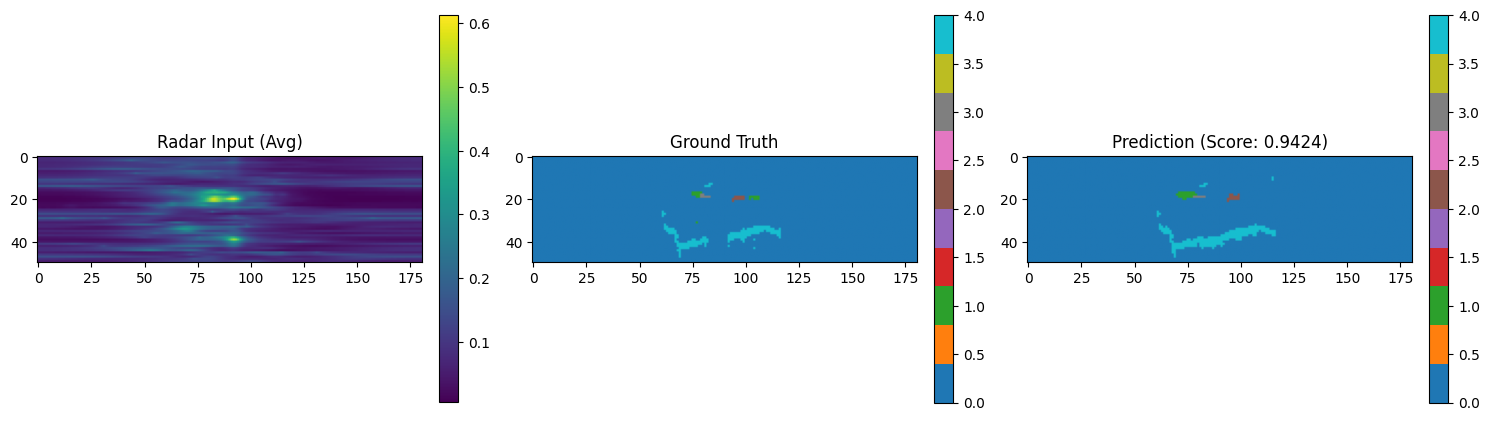

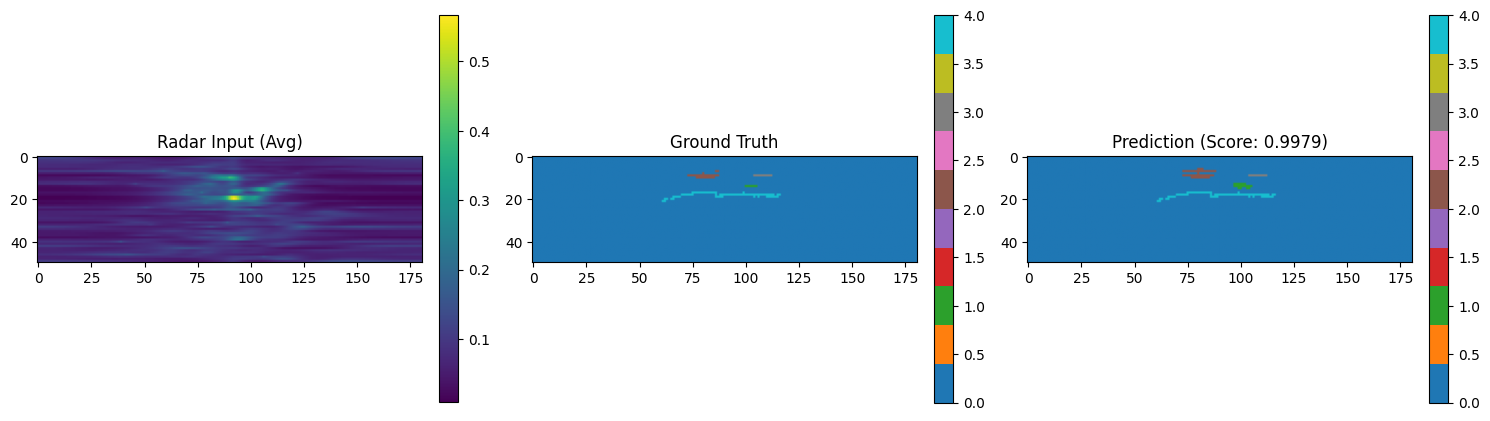

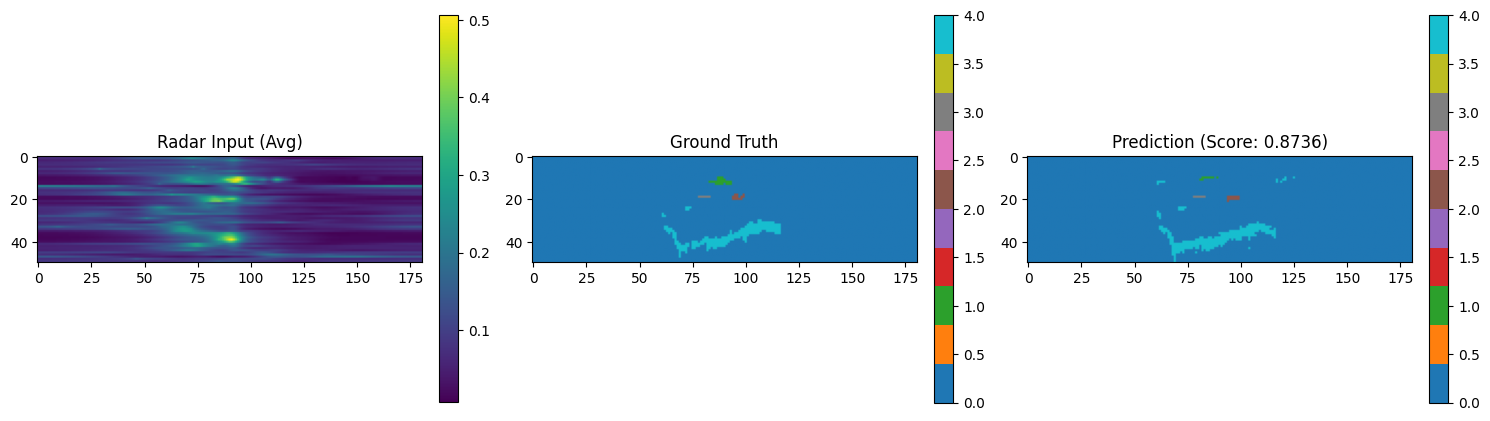

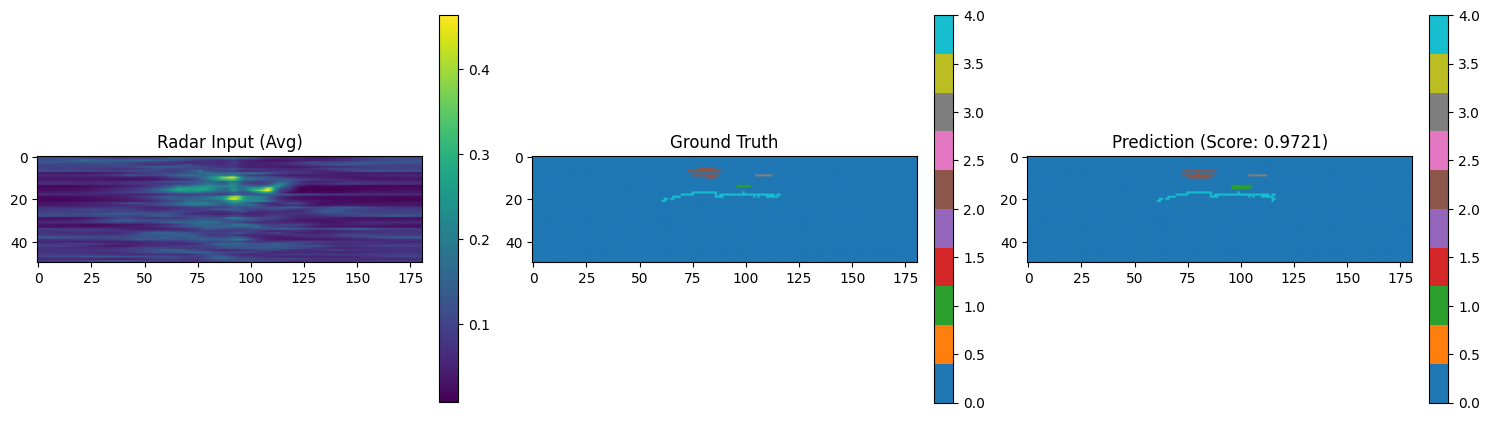

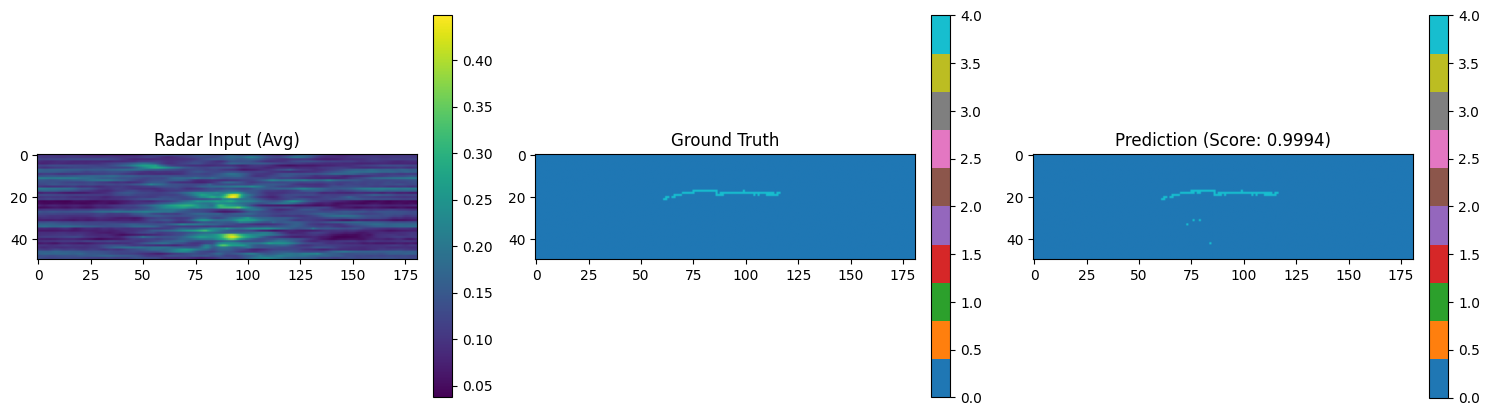

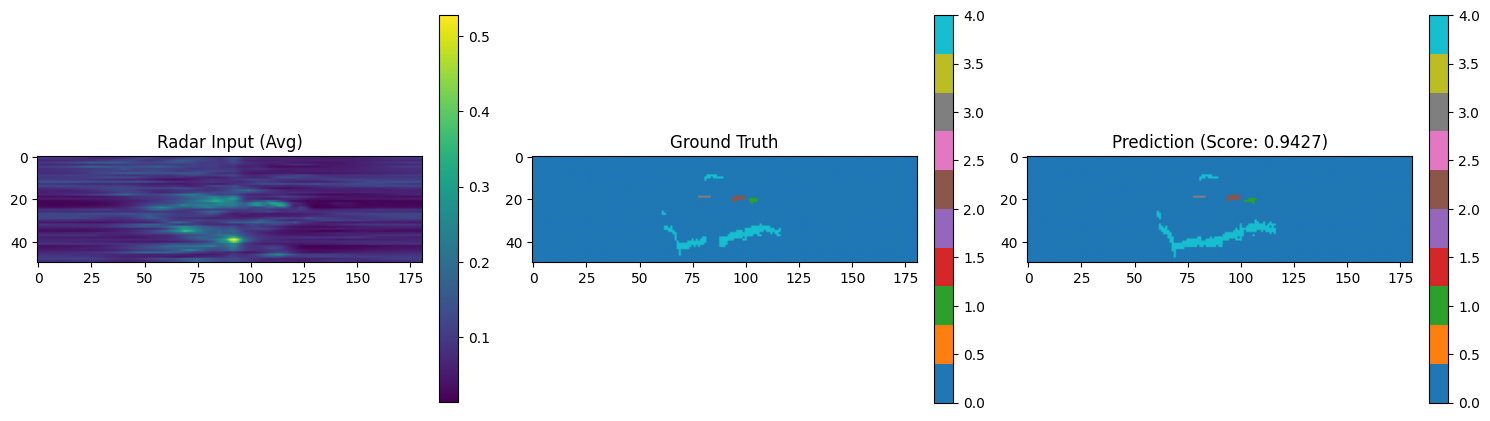

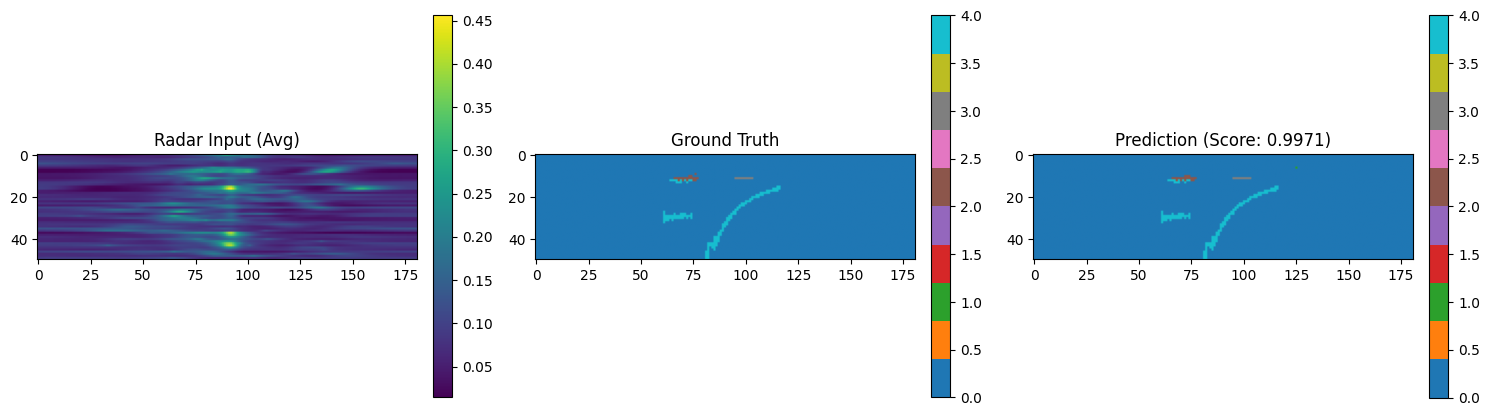

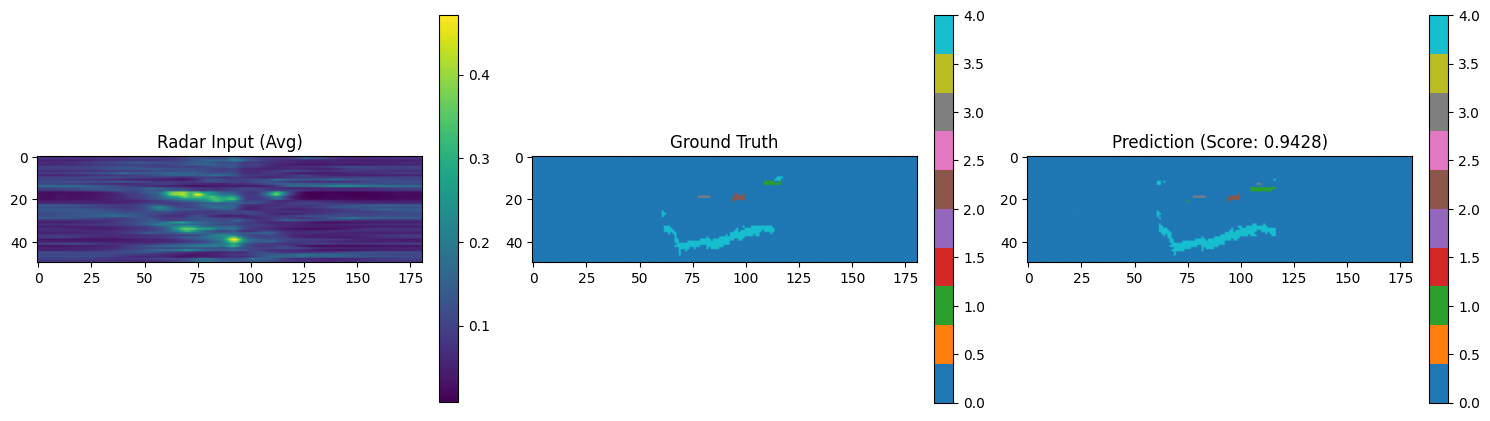

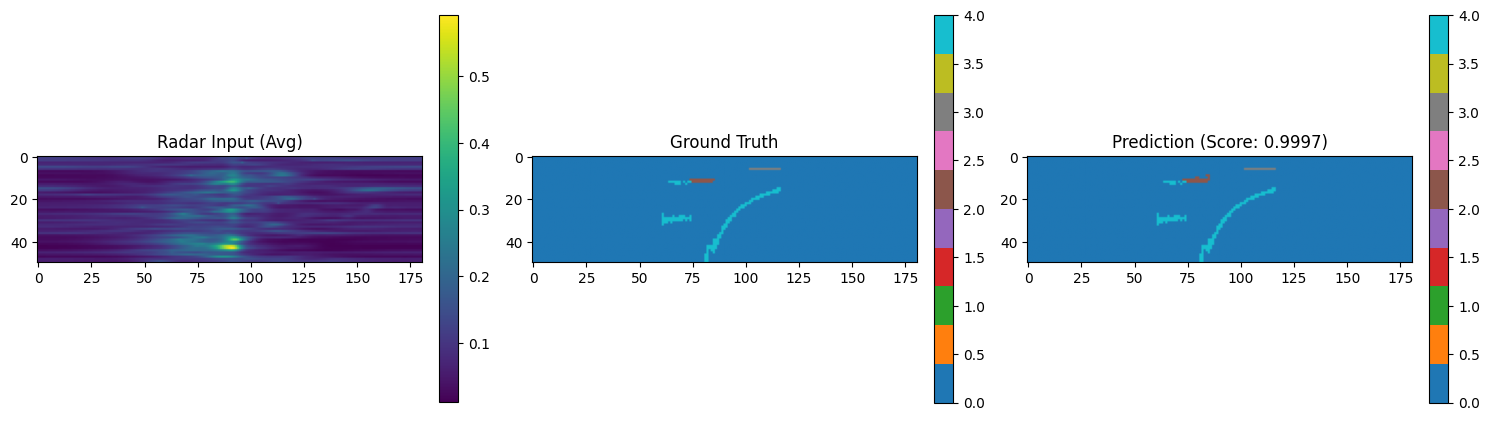

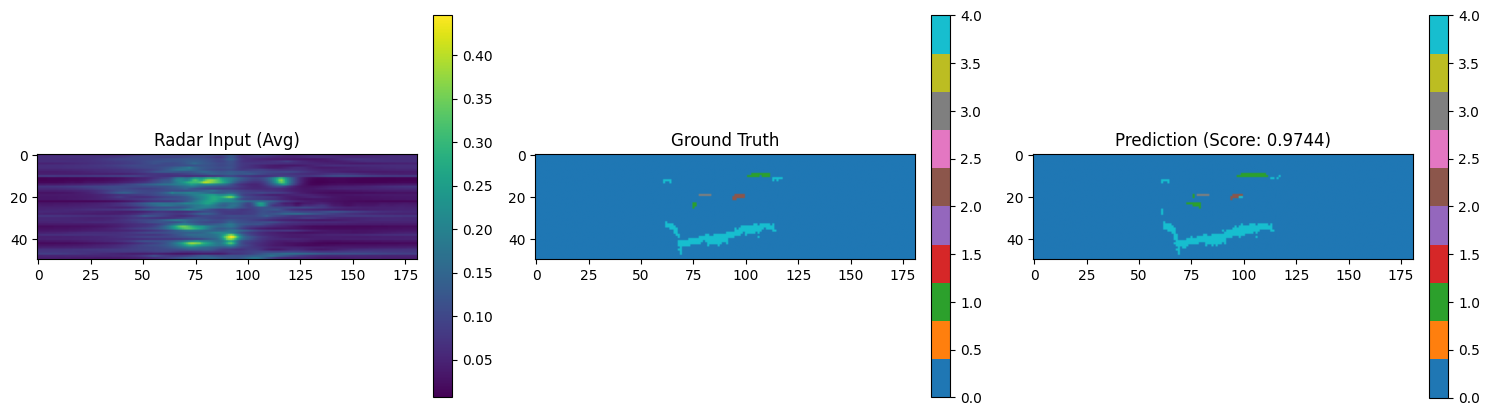

In [ ]:
def evaluate_and_visualize(model, loader, device, num_samples=3):
    model.eval()
    samples_shown = 0

    with torch.no_grad():
        for batch in loader:
            tensors = [item for item in batch if isinstance(item, torch.Tensor)]

            if len(tensors) < 2:
                continue
            if tensors[0].dim() > tensors[1].dim():
                images, labels = tensors[0], tensors[1]
            else:
                labels, images = tensors[0], tensors[1]

            images = images.to(device)
            labels = labels.to(device).long()

            labels = torch.clamp(labels, 0, 4)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    return

                radar_img = images[i].cpu().mean(dim=0).numpy()
                gt_img = labels[i].cpu().numpy()
                pred_img = preds[i].cpu().numpy()

                fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                im0 = axes[0].imshow(radar_img, cmap='viridis')
                axes[0].set_title("Radar Input (Avg)")
                plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

                im1 = axes[1].imshow(gt_img, cmap='tab10', vmin=0, vmax=4)
                axes[1].set_title("Ground Truth")
                plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

                score = get_contest_score(preds[i].unsqueeze(0), labels[i].unsqueeze(0))
                im2 = axes[2].imshow(pred_img, cmap='tab10', vmin=0, vmax=4)
                axes[2].set_title(f"Prediction (Score: {score:.4f})")
                plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

                plt.tight_layout()
                plt.show()

                samples_shown += 1

evaluate_and_visualize(model, test_loader, device, num_samples=10)

In [ ]:
import zipfile
import os

# Define the files to zip and the zip file name.
files_to_zip = ['submission_val.csv', 'submission_test.csv']
zip_filename = 'submission.zip'

# Create a zip file
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        # Add the file to the zip fil
        zipf.write(file, os.path.basename(file))

print(f'{zip_filename} Created successfully!')

## ResNet + U-net

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_rate=0.2):
        super(ResidualBlock, self).__init__()
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )

        self.shortcut = nn.Sequential()
        if in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv_path(x) + self.shortcut(x))

class ResUNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResUNet, self).__init__()

        self.enc1 = ResidualBlock(in_channels, 64)
        self.enc2 = ResidualBlock(64, 128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck_conv = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256)
        )
        self.bottleneck_shortcut = nn.Conv2d(128, 256, kernel_size=1, bias=False)
        self.relu = nn.ReLU(inplace=True)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec_block1 = ResidualBlock(256, 128, dropout_rate=0.2)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec_block2 = ResidualBlock(128, 64, dropout_rate=0.1)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def _match_and_cat(self, x1, x2):
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        return torch.cat([x2, x1], dim=1)

    def forward(self, x):
        s1 = self.enc1(x)
        p1 = self.pool(s1)
        s2 = self.enc2(p1)
        p2 = self.pool(s2)

        b = self.relu(self.bottleneck_conv(p2) + self.bottleneck_shortcut(p2))

        d1 = self.up1(b)
        d1 = self._match_and_cat(d1, s2)
        d1 = self.dec_block1(d1)

        d2 = self.up2(d1)
        d2 = self._match_and_cat(d2, s1)
        d2 = self.dec_block2(d2)

        return self.final_conv(d2)

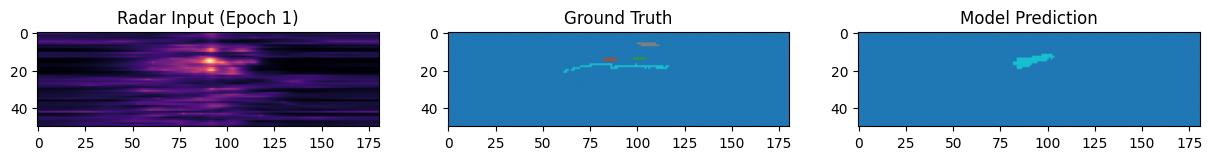

Epoch 1 | Loss: 0.4832 | Contest Score: 0.6505
Epoch 2 | Loss: 0.1729 | Contest Score: 0.9156
Epoch 3 | Loss: 0.1152 | Contest Score: 0.9420
Epoch 4 | Loss: 0.0914 | Contest Score: 0.9485
Epoch 5 | Loss: 0.0777 | Contest Score: 0.9650


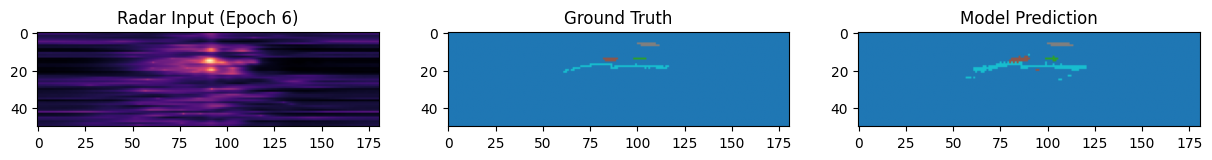

Epoch 6 | Loss: 0.0701 | Contest Score: 0.9649
Epoch 7 | Loss: 0.0637 | Contest Score: 0.9645
Epoch 8 | Loss: 0.0595 | Contest Score: 0.9697
Epoch 9 | Loss: 0.0565 | Contest Score: 0.9742
Epoch 10 | Loss: 0.0536 | Contest Score: 0.9686


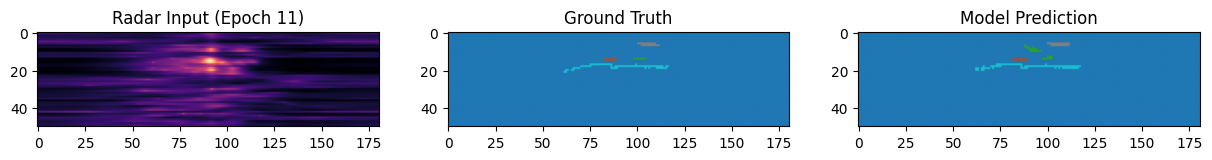

Epoch 11 | Loss: 0.0516 | Contest Score: 0.9679
Epoch 12 | Loss: 0.0494 | Contest Score: 0.9672
Epoch 13 | Loss: 0.0480 | Contest Score: 0.9710
Epoch 14 | Loss: 0.0464 | Contest Score: 0.9712
Epoch 15 | Loss: 0.0450 | Contest Score: 0.9717


In [ ]:
TRAIN_PATH = "/content/IOAI-2025/Individual-Contest/Radar/"
data_path = TRAIN_PATH + 'training_set'

# Assuming load_data is defined elsewhere
train_loader, test_loader = load_data(
    base_path=data_path,
    batch_size=32,
    num_workers=2,
    test_size=0.2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = ResUNet(6, 5)
train_contest_ready(model, train_loader, test_loader, num_epochs=15)

## Attention U-Net


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(AttentionUNet, self).__init__()

        self.enc1 = ConvBlock(in_channels, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = ConvBlock(256, 512)

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.dec1 = ConvBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.dec2 = ConvBlock(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.dec3 = ConvBlock(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def _match_and_cat(self, x1, x2):
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        return torch.cat([x2, x1], dim=1)

    def forward(self, x):
        s1 = self.enc1(x)
        p1 = self.pool(s1)
        s2 = self.enc2(p1)
        p2 = self.pool(s2)
        s3 = self.enc3(p2)
        p3 = self.pool(s3)

        b = self.bottleneck(p3)

        g1 = self.up1(b)
        s3 = self.att1(g=g1, x=s3)
        d1 = self._match_and_cat(g1, s3)
        d1 = self.dec1(d1)

        g2 = self.up2(d1)
        s2 = self.att2(g=g2, x=s2)
        d2 = self._match_and_cat(g2, s2)
        d2 = self.dec2(d2)

        g3 = self.up3(d2)
        s1 = self.att3(g=g3, x=s1)
        d3 = self._match_and_cat(g3, s1)
        d3 = self.dec3(d3)

        return self.final(d3)

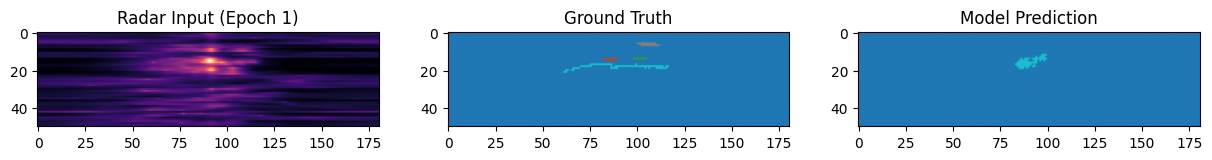

Epoch 1 | Loss: 0.4667 | Contest Score: 0.6777
Epoch 2 | Loss: 0.1725 | Contest Score: 0.9177
Epoch 3 | Loss: 0.1153 | Contest Score: 0.9421
Epoch 4 | Loss: 0.0897 | Contest Score: 0.9595
Epoch 5 | Loss: 0.0770 | Contest Score: 0.9624


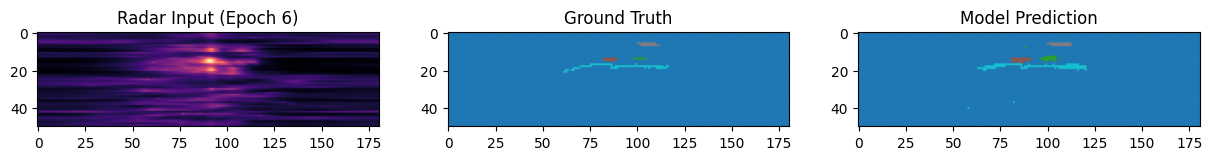

Epoch 6 | Loss: 0.0690 | Contest Score: 0.9691
Epoch 7 | Loss: 0.0636 | Contest Score: 0.9633
Epoch 8 | Loss: 0.0595 | Contest Score: 0.9686
Epoch 9 | Loss: 0.0561 | Contest Score: 0.9731
Epoch 10 | Loss: 0.0538 | Contest Score: 0.9745


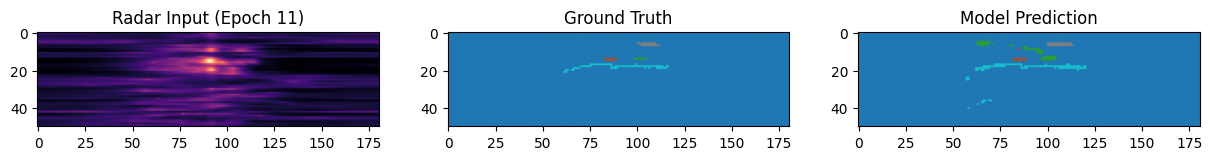

Epoch 11 | Loss: 0.0502 | Contest Score: 0.9748
Epoch 12 | Loss: 0.0493 | Contest Score: 0.9738
Epoch 13 | Loss: 0.0476 | Contest Score: 0.9688
Epoch 14 | Loss: 0.0461 | Contest Score: 0.9692
Epoch 15 | Loss: 0.0447 | Contest Score: 0.9734


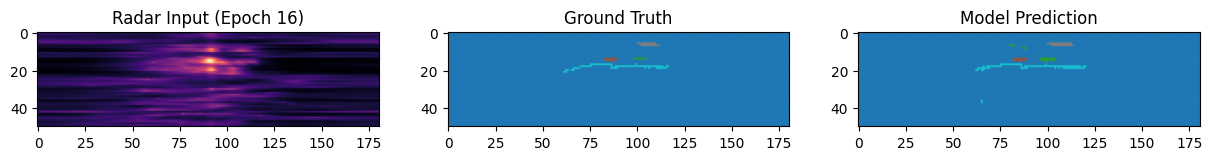

Epoch 16 | Loss: 0.0438 | Contest Score: 0.9703
Epoch 17 | Loss: 0.0424 | Contest Score: 0.9749
Epoch 18 | Loss: 0.0413 | Contest Score: 0.9723
Epoch 19 | Loss: 0.0403 | Contest Score: 0.9705
Epoch 20 | Loss: 0.0394 | Contest Score: 0.9711


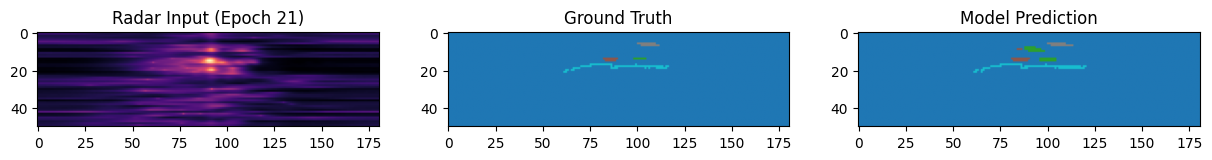

Epoch 21 | Loss: 0.0383 | Contest Score: 0.9731
Epoch 22 | Loss: 0.0380 | Contest Score: 0.9732
Epoch 23 | Loss: 0.0367 | Contest Score: 0.9732
Epoch 24 | Loss: 0.0364 | Contest Score: 0.9673
Epoch 25 | Loss: 0.0355 | Contest Score: 0.9705


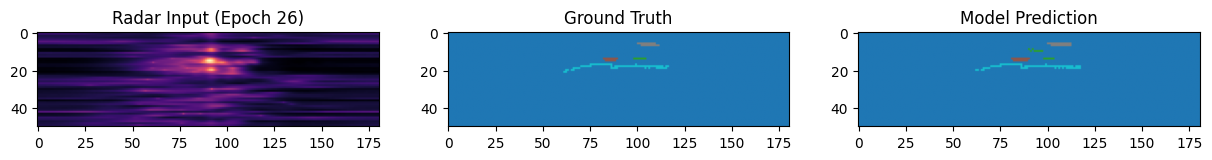

Epoch 26 | Loss: 0.0348 | Contest Score: 0.9726
Epoch 27 | Loss: 0.0339 | Contest Score: 0.9688
Epoch 28 | Loss: 0.0332 | Contest Score: 0.9665
Epoch 29 | Loss: 0.0326 | Contest Score: 0.9664
Epoch 30 | Loss: 0.0320 | Contest Score: 0.9661


In [ ]:
TRAIN_PATH = "/content/IOAI-2025/Individual-Contest/Radar/"
data_path = TRAIN_PATH + 'training_set'

train_loader, test_loader = load_data(
    base_path=data_path,
    batch_size=32,
    num_workers=2,
    test_size=0.2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = ResUNet(6, 5)
train_contest_ready(model, train_loader, test_loader, num_epochs=30)